In [3]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
import sys
sys.path.append(os.path.abspath("../.."))
import warnings
from pandas.errors import PerformanceWarning  # Importation nécessaire

# Ignorer les avertissements de fragmentation de mémoire
warnings.filterwarnings('ignore', category=PerformanceWarning)

root_path = '/home/jadli/Desktop/BDAI2/projects/Credit-risk/data/raw'


In [5]:
# afficher toutes les colonnes dans le output pandas
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# # Pour revenir à l’affichage normal
# pd.reset_option('display.max_rows')
# pd.reset_option('display.max_columns')
# pd.reset_option('display.width')
# pd.reset_option('display.max_colwidth')

In [6]:
# Charger les fichiers de données en utilisant le chemin racine
application_train = pd.read_csv(os.path.join(root_path, 'application_train.csv'))
application_test = pd.read_csv(os.path.join(root_path, 'application_test.csv'))
bureau = pd.read_csv(os.path.join(root_path, 'bureau.csv'))
bureau_balance = pd.read_csv(os.path.join(root_path, 'bureau_balance.csv'))
previous_application = pd.read_csv(os.path.join(root_path, 'previous_application.csv'))
credit_card_balance = pd.read_csv(os.path.join(root_path, 'credit_card_balance.csv'))
# HomeCredit_columns_description = pd.read_csv(os.path.join(root_path, 'HomeCredit_columns_description.csv'))
installments_payments = pd.read_csv(os.path.join(root_path, 'installments_payments.csv'))
POS_CASH_balance = pd.read_csv(os.path.join(root_path, 'POS_CASH_balance.csv'))
# sample_submission = pd.read_csv(os.path.join(root_path, 'sample_submission.csv'))

In [ ]:
from src.data import transform_bureau_tables, transform_application_table

# Supposez que application_train est déjà chargé en tant que DataFrame df_application_train
# Vous avez déjà fusionné bureau et bureau_balance dans le DataFrame final
final = transform_bureau_tables(bureau, bureau_balance)
df_application_train = transform_application_table(application_train)

# Fusionner bureau + bb (final) avec application_train sur SK_ID_CURR
df_merged = df_application_train.merge(final, on='SK_ID_CURR', how='left')

# Affichage du nombre de colonnes après la fusion
print(f"Cols Count after merge: {len(df_merged.columns)}")

# Optionnellement, vous pouvez vérifier un échantillon des données fusionnées
# print(df_merged.head())

Cols Count after merge: 210


In [9]:
df_application_test = transform_application_table(application_test)
df_test_merged = df_application_test.merge(final, on='SK_ID_CURR', how='left')
print(final.shape)
print(df_merged.shape)
print(df_test_merged.shape)

(305811, 27)
(307511, 210)
(48744, 209)


[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.036983 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 16051
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 204
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[14]	valid_0's auc: 0.739111	valid_0's binary_logloss: 0.275882
AUC = 0.7521


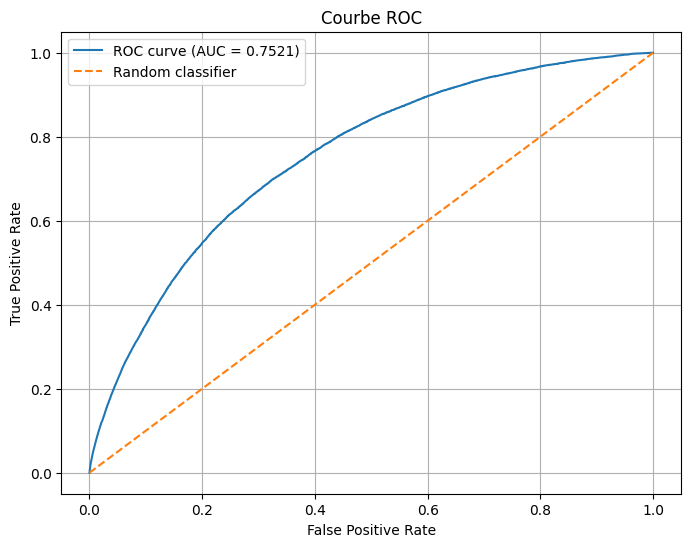

AUC = 0.7391


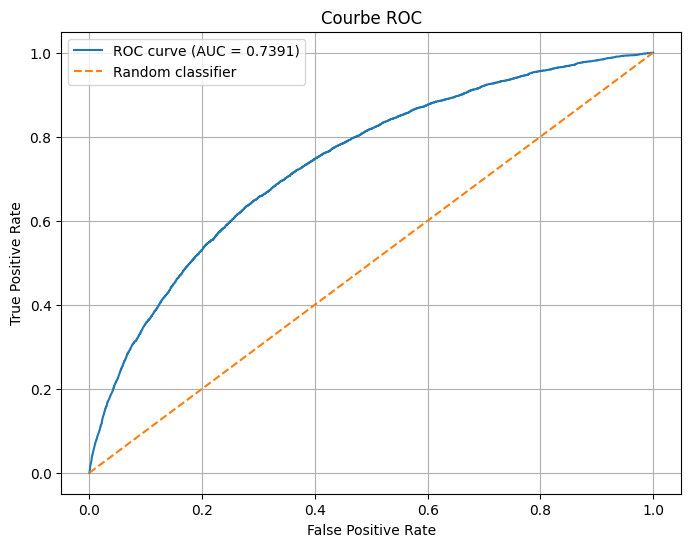

In [7]:
from src.model import train_model
results = train_model(df_merged, df_test_merged)

In [ ]:
from src.data import transform_previous_applications
previous_app_tf = transform_previous_applications(previous_application)
print(previous_app_tf.shape)

(338857, 154)


In [9]:
train_df = df_merged.merge(previous_app_tf, on='SK_ID_CURR', how='left')
test_df = df_test_merged.merge(previous_app_tf, on='SK_ID_CURR', how='left')

In [10]:
print(train_df.shape)
print(test_df.shape)

(307511, 363)
(48744, 362)


[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.052453 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 36006
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 357
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[14]	valid_0's auc: 0.740158	valid_0's binary_logloss: 0.275684
AUC = 0.7563


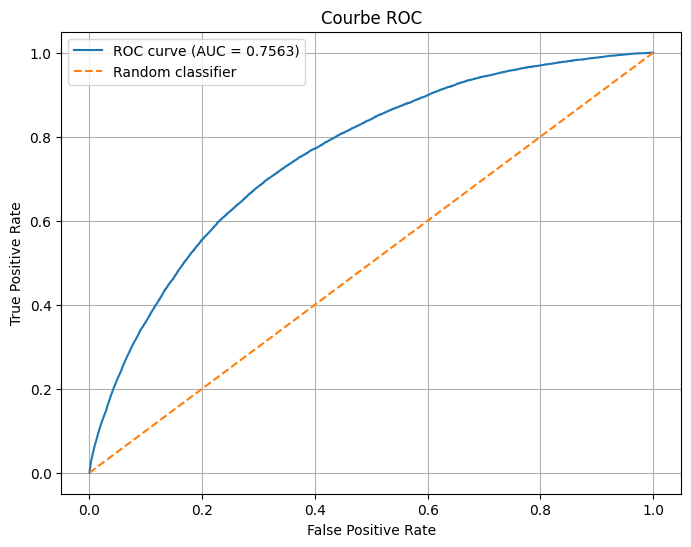

AUC = 0.7402


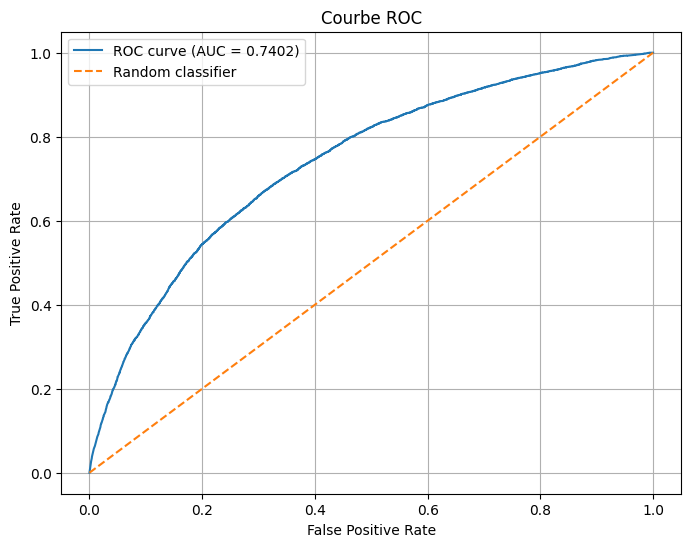

In [11]:
from src.model import train_model
results = train_model(train_df, test_df)